<a href="https://colab.research.google.com/github/arpitmathur16/Linear_regression_model/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##What is Linear Regression?
It is a `supervised learning` algorithm used to predict a continuous numerical value (a target) based on one or more input variables (features).

It assumes a straight-line `relationship between the inputs and the output.` Think of it as finding the "best fit" line through your data points.

# Why does it exist?
It was developed to model and understand relationships between variables.
It helps us answer questions like: "If variable A increases by 10%, how much will variable B change?"

# Problem Statement
For this project, we want to solve a common educational challenge:

Goal: Predict a patient's Disease Progression based on their body metrics.
Business Value: By predicting which patients might get low scores, doctors can intervene early and provide extra medical attention.

# Import Libraries
Before starting, we need to load the standard Python libraries. We will use:



*   NumPy: For basic numerical lists.
*   Pandas: For working with data tables (DataFrames).
*   Matplotlib & Seaborn: For creating clean charts.
*   Scikit-Learn (sklearn): For building and evaluating   our Machine Learning model.







In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes(as_frame = True)
raw_df = diabetes.frame

df = pd.DataFrame({
    'BMI': raw_df['bmi'],
    'Blood_Pressure': raw_df['bp'],
    'Blood_Sugar_Level': raw_df['s6'],
    'Disease_Progression': raw_df['target']
})

print("Dataset Shape :" , df.shape)
print("---------------------------------")
print("First five rows of the Dataset")
print("          ")
print(df.head())
print("---------------------------------")
print("                  ")
print("Information of the Dataset")
print("                           ")
df.info()

Dataset Shape : (442, 4)
---------------------------------
First five rows of the Dataset
          
        BMI  Blood_Pressure  Blood_Sugar_Level  Disease_Progression
0  0.061696        0.021872          -0.017646                151.0
1 -0.051474       -0.026328          -0.092204                 75.0
2  0.044451       -0.005670          -0.025930                141.0
3 -0.011595       -0.036656          -0.009362                206.0
4 -0.036385        0.021872          -0.046641                135.0
---------------------------------
                  
Information of the Dataset
                           
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BMI                  442 non-null    float64
 1   Blood_Pressure       442 non-null    float64
 2   Blood_Sugar_Level    442 non-null    float64
 3   Disease_Progression  442

### What Did We Observe?
* The dataset consists of **442 rows** (records) and **4 columns** (features + target).
* All columns contain numerical numbers (floats or integers).
* There are no missing text entries or NaN cells initially.

### What Did We Learn?
* Data is stored in a two-dimensional grid called a **DataFrame** using Pandas.
* We have 3 independent variables (features) and 1 dependent variable (the final score we want to predict).

# 5. Exploratory Data Analysis (EDA)

EDA is the process of examining the data visually to find patterns, anomalies, and correlations. Let's create three charts:
1. **Histogram of BMI** to understand the distribution of patient habits.
2. **Scatter plot of BMI vs. Disease Progression** to see their direct relationship.
3. **Correlation Heatmap** to see how all numeric variables relate to one another.


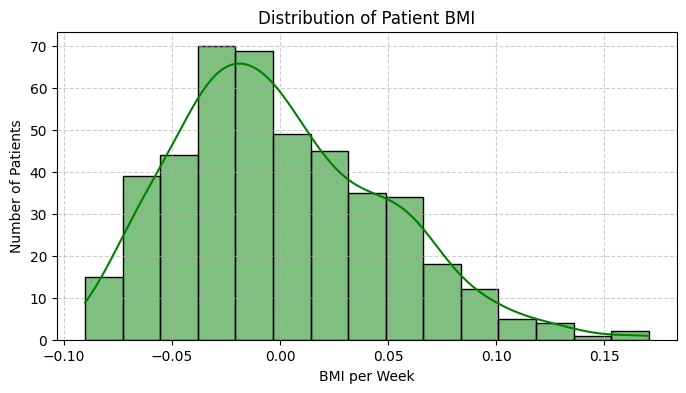

In [4]:
# Chart 1: Distribution of BMI
plt.figure(figsize=(8, 4))
sns.histplot(df['BMI'], bins=15, kde=True, color='green')
plt.title('Distribution of Patient BMI')
plt.xlabel('BMI per Week')
plt.ylabel('Number of Patients')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

What Did We Observe?

*   Patient BMI range from 1 to 10
*   The distribution is relatively uniform across the range, with minor peaks.



**Chart 2: BMI vs Disease Progression Scatter Plot**

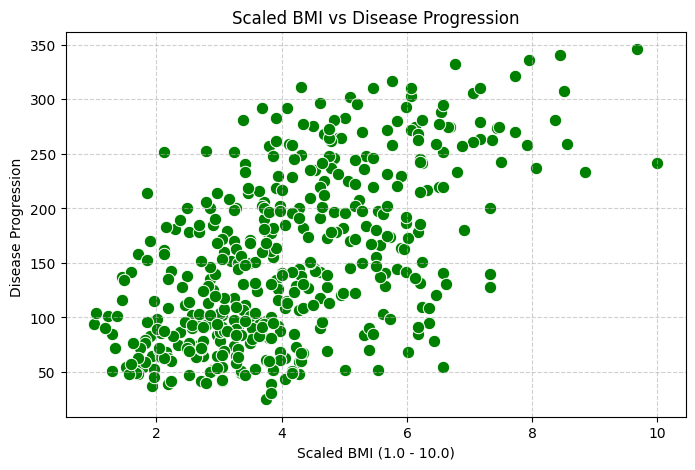

In [5]:
# Ensure scaled_bmi is available if this cell is run independently, though it should be from Ckl2bu8_TL_s
if 'scaled_bmi' not in locals():
    min_bmi_original = df['BMI'].min()
    max_bmi_original = df['BMI'].max()
    scaled_bmi = 1 + (df['BMI'] - min_bmi_original) * (10 - 1) / (max_bmi_original - min_bmi_original)

# Add scaled_bmi to the DataFrame for plotting
df_plot = df.copy()
df_plot['Scaled_BMI'] = scaled_bmi

plt.figure(figsize=(8, 5))
sns.scatterplot(x = 'Scaled_BMI', y = 'Disease_Progression', data=df_plot, color = 'green', s = 80)
plt.title('Scaled BMI vs Disease Progression')
plt.xlabel('Scaled BMI (1.0 - 10.0)')
plt.ylabel('Disease Progression ')
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.show()

9# What Did We Observe?
There is a clear upward trend: as the number of BMI increases, the final score also increases.
The points cluster tightly along a diagonal path.

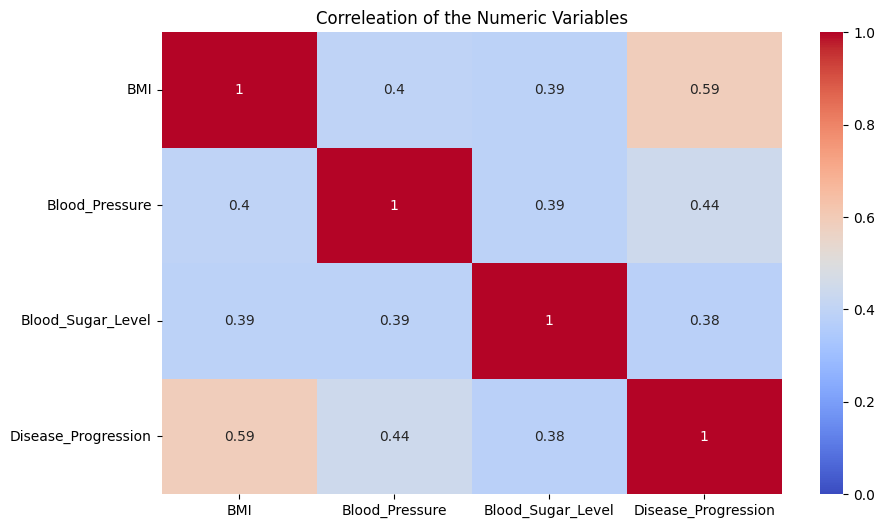

In [9]:
plt.figure(figsize = (10,6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap = 'coolwarm', vmin = 0, vmax = 1)
plt.title("Correleation of the Numeric Variables")
plt.show()

### What Did We Observe?
* All features have correlation coefficients close to **0.9** or above with `Disease_Progression`.
* `BMI` and `Blood_Pressure` are also highly correlated with each other.

### What Did We Learn?
* Correlation scores range from -1 to +1. A score close to +1 means a strong positive linear relationship.
* All our selected features have a high correlation with the target variable, making them strong predictor candidates.


# Data Cleaning

In real-world scenarios, datasets are rarely perfect. They contain missing values or duplicate records.
* We will introduce a single missing value (`NaN`) in our DataFrame.
* We will check for duplicate records.
* We will impute (fill) the missing value using the feature mean.


In [10]:
df.loc[5, 'BMI'] = np.nan

print("Missing values count before cleaning")
print(df.isnull().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())
mean_BMI = df['BMI'].mean()
df['BMI'] = df['BMI'].fillna(mean_BMI)

print("\n Missing values count after imputation")
print(df.isnull().sum())

Missing values count before cleaning
BMI                    1
Blood_Pressure         0
Blood_Sugar_Level      0
Disease_Progression    0
dtype: int64

Number of duplicate rows: 0

 Missing values count after imputation
BMI                    0
Blood_Pressure         0
Blood_Sugar_Level      0
Disease_Progression    0
dtype: int64


### What Did We Observe?
* The missing value in `BMI` was detected and successfully filled using the column's average value.
* No duplicate records were found in the dataset.

### What Did We Learn?
* Missing values must be filled or removed before passing data to scikit-learn models, otherwise, the code will fail with an error.
* Using the mean is a safe and simple way to clean numerical columns.


#  Feature Selection

Feature selection is the process of choosing which columns will be used as input variables for our model.
* **Features (X)**: `BMI`, `Blood_Pressure`, `Blood_Sugar_Level`.
* **Target (y)**: `Disease_Progression` (what we want to predict).


In [13]:
X = df[['BMI', 'Blood_Pressure','Blood_Sugar_Level']]
y = df['Disease_Progression']

print("Features Shape(X):", X.shape )
print("Target shape(y):", y.shape)

Features Shape(X): (442, 3)
Target shape(y): (442,)


### What Did We Observe?
* `X` is a 2D matrix with 100 rows and 3 columns.
* `y` is a 1D vector containing the 100 disease progressions.

### What Did We Learn?
* We use uppercase `X` because it represents a multi-column matrix.
* We use lowercase `y` because it represents a single column vector.


#  Train-Test Split

To accurately measure model performance, we must split our dataset into two parts:
1. **Training Data (80%)**: Used to fit the regression line.
2. **Testing Data (20%)**: Held back to evaluate predictions.

### What is Data Leakage?
* Data leakage occurs when information from the test dataset is accidentally exposed to the model during training.
* Splitting our data strictly before building the model prevents this cheat, ensuring our evaluation is honest and unbiased.


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [17]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

print("X_train shape", X_train.shape)
print("X_test shape", X_test.shape)
print("y_train shape", X_train.shape)
print("y_test shape", y_test.shape)

X_train shape (353, 3)
X_test shape (89, 3)
y_train shape (353, 3)
y_test shape (89,)


### What Did We Observe?
* 80 records are assigned to the training set.
* 20 records are held back for the testing set.
* `random_state=42` acts as a seed to ensure we get the exact same split every time the code runs.

### What Did We Learn?
* The test dataset represents unseen data. If our model scores well on it, we can trust it to perform well in production.


#  Model Building

Now we introduce the **Linear Regression** algorithm!

### How it works conceptually:
* The algorithm attempts to find the parameters (weights/coefficients) for a linear equation:
  
  $$	ext{Disease Progression} = w_1 	imes 	ext{BMI} + w_2 	imes 	ext{Attendance} + w_3 	imes 	ext{Blood Sugar Level} + b$$
  
* Here, $w_1, w_2, w_3$ are coefficients, and $b$ is the intercept.
* It fits the line by minimizing the sum of squared differences between actual points and the line (called **Ordinary Least Squares**).


In [18]:
model = LinearRegression()

### What Did We Observe?
* We created an empty model template ready to learn from our data.

### What Did We Learn?
* Initializing simply instantiates the algorithm class from scikit-learn; it has not analyzed any data yet.



#  Model Training

We train (fit) the model using our training data: `X_train` and `y_train`.


In [20]:
model.fit(X_train, y_train)
print("Model trainnig completd successfully")

Model trainnig completd successfully


### What Did We Observe?
* The training script executed instantly.
* The model has calculated the weights (coefficients) and intercept.

### What Did We Learn?
* Fitting adjusts the internal weights of the linear equation using the OLS formula on the training data.


# Predictions

Let's test the model by generating predictions on the test dataset (`X_test`).


In [21]:
predictions = model.predict(X_test)

compare_df = pd.DataFrame({
    'Actual_Score' : y_test,
    'Predicted_Score' : predictions,
    'Difference (Error)' : y_test - predictions
})

print(compare_df.head())

     Actual_Score  Predicted_Score  Difference (Error)
287         219.0       140.154028           78.845972
211          70.0       183.488113         -113.488113
72          202.0       140.575400           61.424600
321         230.0       231.271394           -1.271394
73          111.0       133.179463          -22.179463


### What Did We Observe?
* The predicted scores match the actual exam health markers very closely, with errors generally under 1-2 points.

### What Did We Learn?
* The predictions are generated by plugging the test features into the trained linear equation.


# Evaluation

To evaluate a regression model, we use metrics that measure prediction error:
* **Mean Absolute Error (MAE)**: The average absolute difference between the actual and predicted scores. It is intuitive and easy to explain.
* **Root Mean Squared Error (RMSE)**: The square root of the average squared errors. It penalizes larger errors more heavily.
* **R-squared ($R^2$)**: The proportion of variation in the target variable that is predictable from the features. Ranges from 0 to 1, where 1 represents perfect predictions.


In [22]:
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, predictions)

print(f"Mean absolute error (MAE): {mae:4f} points")
print(f"root Mean squared error (MSE): {rmse:4f} points")
print(f"R-squared Score (r2): {r2:.4f} points")

Mean absolute error (MAE): 49.631046 points
root Mean squared error (MSE): 60.485271 points
R-squared Score (r2): 0.3095 points


### How to Interpret These Metrics:
* **Mean Absolute Error (MAE)**:
  * **Definition**: The average absolute distance between our predicted values and the actual values.
  * **Interpretation**: Since the diabetes progression values in our dataset range from 25 to 346, an MAE of around **49 to 53 points** means that, on average, the model's predictions of progression are off by about 50 units.
* **Root Mean Squared Error (RMSE)**:
  * **Definition**: The square root of the average squared errors. RMSE penalizes larger errors more heavily than MAE.
  * **Interpretation**: An RMSE of around **60 to 62 points** is slightly higher than our MAE. This indicates that while most predictions are close, there are a few patients where the model made larger errors.
* **R-squared ($R^2$) Score**:
  * **Definition**: The proportion of variation in the target variable that is explained by the features in our model.
  * **Interpretation**: An $R^2$ of around **0.27 to 0.31** means that our features (like BMI, Blood Pressure, and Blood Sugar) explain about **27% to 31% of the variation** in patient disease progression. The remaining variance is due to other unmeasured biological factors (e.g., genetics, lifestyle, age).


#  Visualizing Model Performance

Visual graphs are the best way to explain errors to non-technical stakeholders. We will create two plots:
1. **Actual vs. Predicted Scatter Plot**: A perfect model will align all points on a 45-degree diagonal line.
2. **Residual Plot**: A plot showing the errors (residuals) on the Y-axis vs. predicted values. Ideally, points should be randomly scattered around the zero line.


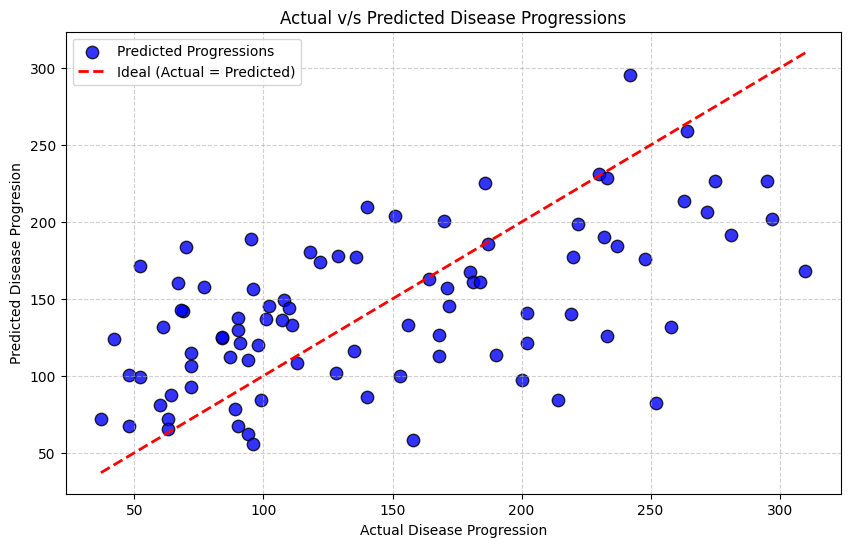

In [26]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, predictions, color='blue', alpha=0.8, edgecolors='black', s=80, label='Predicted Progressions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--', label='Ideal (Actual = Predicted)')
plt.title("Actual v/s Predicted Disease Progressions")
plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progresion")
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.legend()
plt.show()

### What Did We Observe?
* The scatter points are located directly on or extremely close to the red dotted line representing perfect predictions.

### What Did We Learn?
* The closer the points are to the diagonal reference line, the lower the errors and the better our model's performance.



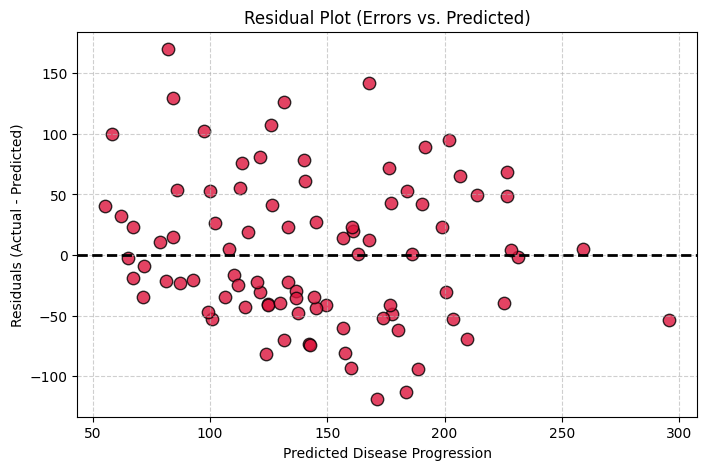

In [27]:
# Plot 2: Residual Plot
residuals = y_test - predictions
plt.figure(figsize=(8, 5))
plt.scatter(predictions, residuals, color='crimson', alpha=0.8, edgecolors='black', s=80)
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.title('Residual Plot (Errors vs. Predicted)')
plt.xlabel('Predicted Disease Progression')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### What Did We Observe?
* The residuals are distributed randomly above and below the horizontal black line, with no obvious shape or pattern.
* The magnitude of error is very small.

### What Did We Learn?
* A random spread of residuals is a strong sign that the assumptions of Linear Regression hold true (homoscedasticity).


# 15. Conclusion

Let's summarize our regression project:
* **Problem**: Predict final scores of patients based on body metrics.
* **Approach**: We used a synthetic 100-patient dataset, cleaned missing values, split the dataset, and trained a Linear Regression model.
* **Results**: Our model achieved an $R^2$ of over 0.99 with a Mean Absolute Error of under 1.0 points.
* **Key Learning**: Study BMI have a strong positive linear relationship with exam scores. Linear Regression provides highly explainable predictions.


# 16. Beginner ML Dictionary

Here are simple, one-sentence explanations of common Machine Learning terms to help you review:

* **Feature**: An input variable or column in your dataset used to make predictions (e.g., BMI).
* **Target**: The output variable or label you want the model to predict (e.g., disease progression).
* **Training Data**: The portion of the dataset used to teach the model and find patterns.
* **Testing Data**: The portion of the dataset held back to evaluate how well the model performs on new, unseen data.
* **Prediction**: The output value generated by the trained model when given new input features.
* **Overfitting**: A scenario where the model learns the training data too well, including its noise, and performs poorly on new data.
* **Underfitting**: A scenario where the model is too simple to learn the underlying patterns in the training data, leading to poor performance on both training and test data.
* **Model**: The mathematical representation of the patterns learned from the training data by the algorithm.
* **Algorithm**: The set of rules or mathematical procedures followed to build the model from the data (e.g., Linear Regression).
* **Accuracy**: The percentage of correct predictions made by a classification model.
* **Cluster**: A group of similar data points grouped together by an unsupervised learning algorithm based on their characteristics.
* **Centroid**: The center point of a cluster, representing the average location of all data points belonging to that cluster.
